In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/movies.csv')
print("Shape:", df.shape)
print("\nNull counts:\n", df.isnull().sum().sort_values(ascending=False))
print("\nContent types:", df['content_type'].value_counts())
print("\nGenres:", df['genre_primary'].value_counts().head(10))
df.head(3)

Shape: (1040, 18)

Null counts:
 number_of_seasons      751
number_of_episodes     719
box_office_revenue     709
production_budget      675
genre_secondary        667
imdb_rating            150
movie_id                 0
added_to_platform        0
is_netflix_original      0
country_of_origin        0
title                    0
language                 0
rating                   0
duration_minutes         0
release_year             0
genre_primary            0
content_type             0
content_warning          0
dtype: int64

Content types: content_type
Movie              458
TV Series          267
Documentary        142
Stand-up Comedy    119
Limited Series      54
Name: count, dtype: int64

Genres: genre_primary
Adventure      72
War            62
Sci-Fi         60
Comedy         60
Action         60
Animation      59
Western        55
History        54
Romance        54
Documentary    52
Name: count, dtype: int64


,movie_id,title,content_type,genre_primary,genre_secondary,release_year,duration_minutes,rating,language,country_of_origin,imdb_rating,production_budget,box_office_revenue,number_of_seasons,number_of_episodes,is_netflix_original,added_to_platform,content_warning
0,movie_0001,Dragon Legend,Stand-up Comedy,History,Thriller,2014,35.0,TV-Y,French,Japan,NaN,NaN,NaN,NaN,NaN,False,2023-08-07,False
1,movie_0002,Storm Warrior,Stand-up Comedy,Sci-Fi,NaN,2017,37.0,PG,Japanese,USA,3.3,NaN,NaN,NaN,NaN,False,2022-01-28,True
2,movie_0003,Fire Family,Movie,Drama,NaN,2003,142.0,TV-MA,English,USA,8.5,2114120.0,NaN,NaN,NaN,False,2021-05-04,True


In [3]:
df_clean = df.copy()

# Genre secondary null → "None"
df_clean['genre_secondary'] = df_clean['genre_secondary'].fillna('None')

# Budget/revenue — flag karo
df_clean['has_budget'] = df_clean['production_budget'].notna()
df_clean['has_revenue'] = df_clean['box_office_revenue'].notna()

# IMDB rating null → median se fill
median_imdb = df_clean['imdb_rating'].median()
df_clean['imdb_rating'] = df_clean['imdb_rating'].fillna(median_imdb)

# Date column parse karo
df_clean['added_to_platform'] = pd.to_datetime(df_clean['added_to_platform'])
df_clean['added_year'] = df_clean['added_to_platform'].dt.year
df_clean['added_month'] = df_clean['added_to_platform'].dt.month

print("Clean shape:", df_clean.shape)
df_clean.isnull().sum()

Clean shape: (1040, 22)


movie_id                 0
title                    0
content_type             0
genre_primary            0
genre_secondary          0
release_year             0
duration_minutes         0
rating                   0
language                 0
country_of_origin        0
imdb_rating              0
production_budget      675
box_office_revenue     709
number_of_seasons      751
number_of_episodes     719
is_netflix_original      0
added_to_platform        0
content_warning          0
has_budget               0
has_revenue              0
added_year               0
added_month              0
dtype: int64

In [4]:
# ROI calculated field
df_clean['roi'] = df_clean['box_office_revenue'] / df_clean['production_budget']

# Decade column
df_clean['decade'] = (df_clean['release_year'] // 10) * 10

# Save clean CSV
df_clean.to_csv('../data/netflix_clean.csv', index=False)
print("Saved! Shape:", df_clean.shape)

Saved! Shape: (1040, 24)


/opt/homebrew/lib/python3.11/site-packages/missingno/missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


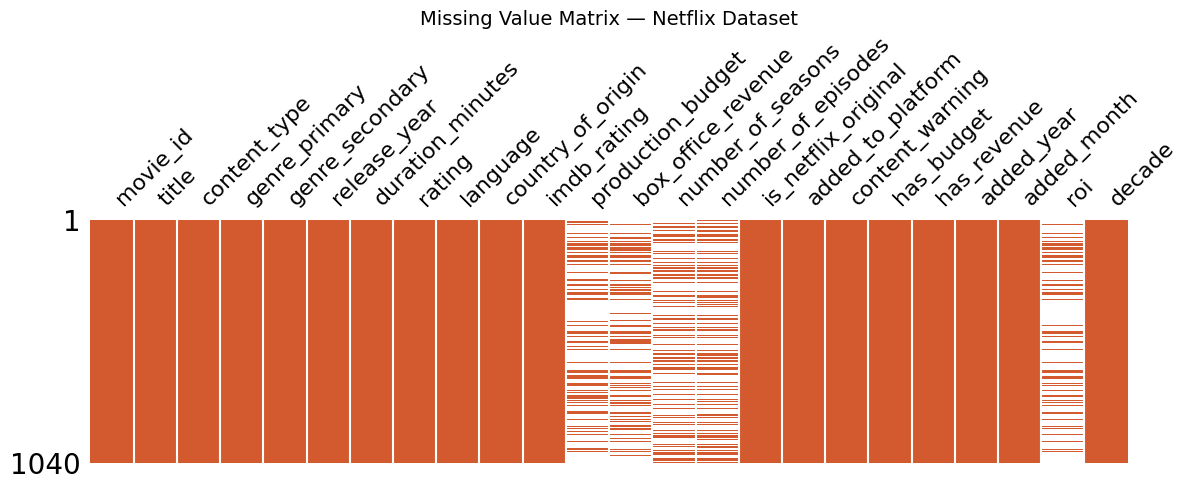

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
msno.matrix(df_clean, ax=ax, color=(0.831, 0.353, 0.188))
plt.title('Missing Value Matrix — Netflix Dataset', fontsize=14)
plt.tight_layout()
plt.savefig('../charts/00_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()